# Como o limiar do guardrail foi escolhido

**Estudo de caso FIESC 02198/2026 — evidência dos ADR-010**

O guardrail que impede o sistema de recomendar sem respaldo documental tem **duas
barreiras**, e elas são de naturezas diferentes.

A **primeira** é o mapa defeito → documento: consulta a dicionário, determinística, sem
parâmetro algum a ajustar. Se o defeito não tem procedimento cadastrado, não há o que
recuperar e não há o que gerar. Nenhuma formulação de pergunta a contorna.

A **segunda** cobre um caso que a primeira não alcança: *o documento existe, mas nenhuma
seção dele responde à pergunta feita*. "O procedimento de desalinhamento fala sobre troca de
óleo?" — existe documento para `desalinhado`, e ainda assim a resposta correta é não sei.

Esse julgamento exige um corte numérico. **E um corte arbitrário é indefensável** — é o tipo
de constante que, numa entrevista, a pergunta seguinte é "por que 0,84 e não 0,80?".

Este notebook responde essa pergunta com medição, e conta junto o erro que a primeira
tentativa cometeu — porque o erro é mais instrutivo que o acerto.

> Reexecutável: requer a base documental indexada em `storage/`. A medição leva cerca de
> um minuto, dominada pelo cálculo dos embeddings.

In [1]:
import os
import sys
import warnings
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

# O sentence-transformers importa tqdm.auto, que avisa sobre widgets de progresso
# ausentes. É ruído de ambiente, não do experimento, e sujaria a saída publicada.
warnings.filterwarnings("ignore", message=".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scripts.calibrar_limiar import escolher_limiar, medir, montar_casos
from src.rag.indice_documental import IndiceDocumental
from src.rag.roteador import LIMIAR_RELEVANCIA, montar_consulta

ACENTO, SUCESSO, ALERTA, CRITICO = "#0369A1", "#059669", "#D97706", "#BE123C"
TINTA, SECUNDARIA, SUAVE, GRADE = "#0F172A", "#475569", "#64748B", "#EDEDF1"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.edgecolor": SUAVE, "axes.labelcolor": SECUNDARIA,
    "axes.titlecolor": TINTA, "axes.titleweight": "semibold",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "grid.color": GRADE, "figure.facecolor": "white",
})

## 1. O conjunto de calibração

Calibrar exige perguntas cuja resposta certa já se conhece. São 44, dirigidas a documentos
específicos e divididas em quatro grupos:

- **pertinentes** — o documento roteado de fato responde;
- **impertinentes** — assunto tecnicamente legítimo, porém **ausente** daquele documento.

Cada grupo tem versões **longas** e **curtas**. Essa divisão não é decorativa — é o achado
central deste notebook, e a seção 4 mostra por quê.

As impertinentes são escritas no mesmo registro técnico das pertinentes, de propósito: se
uma delas fosse "qual a capital da França", a separação medida viria do estilo do texto e
não do conteúdo, e o limiar não descreveria o sistema.

In [2]:
casos = montar_casos()

resumo = pd.DataFrame({
    "grupo": ["pertinente longa", "pertinente curta",
              "impertinente longa", "impertinente curta"],
    "perguntas": [
        sum(1 for k in casos if k.pertinente and not k.curta),
        sum(1 for k in casos if k.pertinente and k.curta),
        sum(1 for k in casos if not k.pertinente and not k.curta),
        sum(1 for k in casos if not k.pertinente and k.curta),
    ],
})
print(f"{len(casos)} perguntas de calibração\n")
print(resumo.to_string(index=False))

print("\nexemplos:")
for k in [next(k for k in casos if k.pertinente and not k.curta),
          next(k for k in casos if k.pertinente and k.curta),
          next(k for k in casos if not k.pertinente and not k.curta),
          next(k for k in casos if not k.pertinente and k.curta)]:
    marca = "pertinente  " if k.pertinente else "impertinente"
    print(f"  [{marca}] {k.documento} · {k.condicao}\n      \"{k.pergunta}\"")

44 perguntas de calibração

             grupo  perguntas
  pertinente longa         16
  pertinente curta          8
impertinente longa         14
impertinente curta          6

exemplos:
  [pertinente  ] Doc1 · rolamento_inner
      "como corrigir um defeito na pista interna do rolamento"
  [pertinente  ] Doc6 · cocked_rotor
      "o eixo pode estar empenado?"
  [impertinente] Doc1 · rolamento_inner
      "como corrigir a falta de fase na alimentação trifásica"
  [impertinente] Doc6 · cocked_rotor
      "e a rede Profibus?"


## 2. A medição usa o mesmo caminho da produção

Cada pergunta passa por `montar_consulta`, exatamente como o roteador faz em operação, e a
relevância registrada é a do melhor trecho recuperado dentro do documento roteado.

Isso parece um detalhe de implementação e não é. Medir por um caminho e operar por outro
produziria um corte que não descreve o sistema — a versão anterior deste procedimento errou
justamente aí, como a seção 4 detalha.

In [3]:
print("o que a produção realmente envia ao índice:\n")
exemplo = next(k for k in casos if k.pertinente and k.curta)
print(f'  pergunta do técnico : "{exemplo.pergunta}"')
print(f'  consulta ao índice  : "{montar_consulta(exemplo.condicao, exemplo.pergunta)}"')

o que a produção realmente envia ao índice:

  pergunta do técnico : "o eixo pode estar empenado?"
  consulta ao índice  : "cocked rotor: o eixo pode estar empenado?"


In [4]:
indice = IndiceDocumental()
medidas = medir(indice)

dados = pd.DataFrame([
    {
        "documento": k.documento,
        "condicao": k.condicao,
        "pergunta": k.pergunta,
        "pertinente": k.pertinente,
        "curta": k.curta,
        "relevancia": r,
        "grupo": ("pertinente " if k.pertinente else "impertinente ")
                 + ("curta" if k.curta else "longa"),
    }
    for k, r in medidas
])
print(f"{len(dados)} medições · índice com {indice.total_trechos} trechos")

44 medições · índice com 115 trechos


## 3. As quatro distribuições

Aqui o problema aparece inteiro.

In [5]:
ordem = ["pertinente longa", "pertinente curta",
         "impertinente longa", "impertinente curta"]
cores = {"pertinente longa": SUCESSO, "pertinente curta": ACENTO,
         "impertinente longa": ALERTA, "impertinente curta": CRITICO}

estatisticas = (
    dados.groupby("grupo")["relevancia"]
    .agg(n="size", minimo="min", mediana="median", maximo="max")
    .reindex(ordem)
)
print(estatisticas.to_string(float_format=lambda v: f"{v:.4f}"))

                     n  minimo  mediana  maximo
grupo                                          
pertinente longa    16  0.8728   0.8928  0.9229
pertinente curta     8  0.8407   0.8513  0.8763
impertinente longa  14  0.8163   0.8449  0.8646
impertinente curta   6  0.8243   0.8352  0.8467


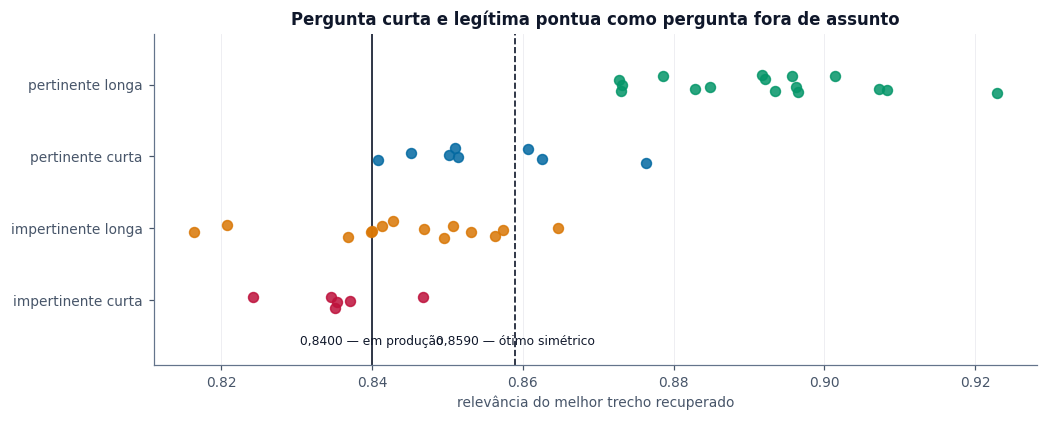

In [6]:
fig, ax = plt.subplots(figsize=(9.6, 3.9))
gerador = np.random.default_rng(0)

for i, grupo in enumerate(ordem):
    v = dados.loc[dados["grupo"] == grupo, "relevancia"].to_numpy()
    ax.scatter(v, np.full_like(v, i) + gerador.uniform(-0.13, 0.13, len(v)),
               s=42, color=cores[grupo], alpha=0.85, zorder=3)

for corte, estilo, rotulo in [(0.8400, "-", "0,8400 — em produção"),
                              (0.8590, "--", "0,8590 — ótimo simétrico")]:
    ax.axvline(corte, color=TINTA, linestyle=estilo, linewidth=1.1, zorder=2)
    ax.text(corte, 3.62, rotulo, fontsize=8, color=TINTA, ha="center")

ax.set_yticks(range(len(ordem)), ordem)
ax.invert_yaxis()
ax.set_xlabel("relevância do melhor trecho recuperado")
ax.set_title("Pergunta curta e legítima pontua como pergunta fora de assunto")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_ylim(3.9, -0.7)
fig.tight_layout()
plt.show()

Duas leituras, e a segunda é a que importa.

**As pertinentes longas separam-se perfeitamente das impertinentes.** A mais fraca delas
pontua acima da impertinente mais forte — há uma faixa vazia entre os dois conjuntos, e
qualquer corte dentro dela classifica tudo corretamente.

**As pertinentes curtas caem em cima da faixa impertinente.** São perguntas legítimas, sobre
o assunto do documento, e mesmo assim pontuam como se estivessem fora dele.

O motivo é mecânico: a similaridade de cosseno entre embeddings é sensível ao **comprimento
do texto**. Uma pergunta de quatro palavras carrega pouca massa semântica, e a similaridade
com um trecho de procedimento cai — independentemente de o assunto ser o mesmo.

## 4. Por que a primeira calibração falhou

A versão inicial deste procedimento usava **apenas perguntas longas e bem formuladas** — 30
delas. O resultado foi excelente: separação limpa, sem sobreposição alguma, limiar em
**0,8569**, 16/16 e 14/14.

Um número obtido com rigor. E errado.

Porque quando o chat entrou no ar, perguntas como *"o eixo pode estar empenado?"* passaram a
ser **recusadas**. O sistema respondia que não havia procedimento — para uma pergunta
diretamente coberta pelo documento roteado.

O conjunto de calibração não representava o uso. Ele media o sistema respondendo a um tipo
de pergunta que ninguém faz num chat.

O gráfico acima reconstrói o erro: **considerando só a metade superior**, a separação de
fato existe e o corte alto parece seguro. É a metade que faltava que derruba a conclusão.

In [7]:
longas = dados[~dados["curta"]]
pertinentes_longas = longas.loc[longas["pertinente"], "relevancia"]
impertinentes_longas = longas.loc[~longas["pertinente"], "relevancia"]

print("Se o conjunto tivesse apenas perguntas longas, como na primeira calibração:")
print(f"  pertinente mais fraca ..... {pertinentes_longas.min():.4f}")
print(f"  impertinente mais forte ... {impertinentes_longas.max():.4f}")
print(f"  separação ................. "
      f"{'SIM' if pertinentes_longas.min() > impertinentes_longas.max() else 'não'}"
      f"  (faixa vazia de {pertinentes_longas.min() - impertinentes_longas.max():.4f})")

print("\nCom o conjunto completo, que inclui como o técnico de fato escreve:")
print(f"  pertinente mais fraca ..... {dados.loc[dados['pertinente'], 'relevancia'].min():.4f}")
print(f"  impertinente mais forte ... {dados.loc[~dados['pertinente'], 'relevancia'].max():.4f}")
print(f"  separação ................. "
      f"{'SIM' if dados.loc[dados['pertinente'],'relevancia'].min() > dados.loc[~dados['pertinente'],'relevancia'].max() else 'NÃO — as distribuições se sobrepõem'}")

Se o conjunto tivesse apenas perguntas longas, como na primeira calibração:
  pertinente mais fraca ..... 0.8728
  impertinente mais forte ... 0.8646
  separação ................. SIM  (faixa vazia de 0.0081)

Com o conjunto completo, que inclui como o técnico de fato escreve:
  pertinente mais fraca ..... 0.8407
  impertinente mais forte ... 0.8646
  separação ................. NÃO — as distribuições se sobrepõem


**Não existe corte perfeito.** Com o conjunto realista, alguma pergunta legítima pontua
abaixo de alguma impertinente, e nenhum limiar acerta os dois lados.

Isso muda a natureza da escolha: deixa de ser "achar o corte que separa" e passa a ser
**decidir qual dos dois erros se prefere cometer**.

## 5. O trade-off, explicitado

Cada corte possível entrega um par de números. A escolha é entre eles.

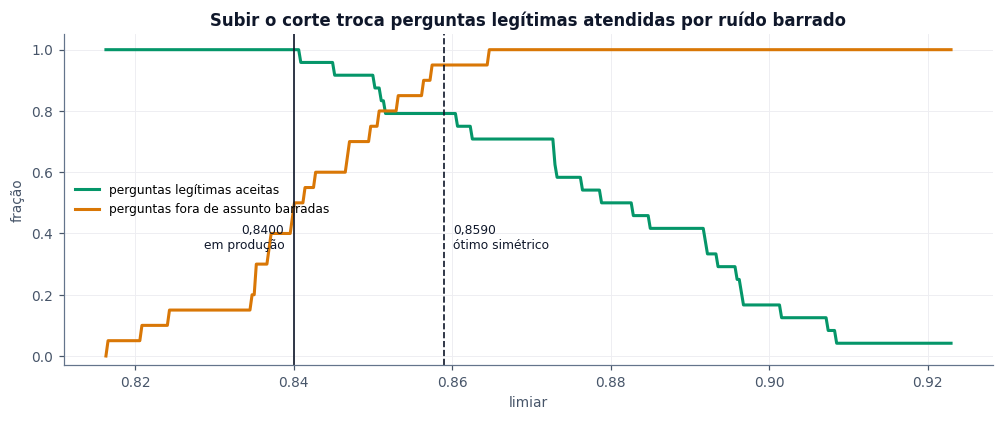

In [8]:
pertinentes = dados.loc[dados["pertinente"], "relevancia"].to_numpy()
impertinentes = dados.loc[~dados["pertinente"], "relevancia"].to_numpy()

grade = np.linspace(dados["relevancia"].min(), dados["relevancia"].max(), 400)
aceitas = [(pertinentes >= c).mean() for c in grade]
barradas = [(impertinentes < c).mean() for c in grade]

fig, ax = plt.subplots(figsize=(9.2, 3.9))
ax.plot(grade, aceitas, color=SUCESSO, linewidth=2, label="perguntas legítimas aceitas")
ax.plot(grade, barradas, color=ALERTA, linewidth=2, label="perguntas fora de assunto barradas")

for corte, estilo in [(LIMIAR_RELEVANCIA, "-"), (0.8590, "--")]:
    ax.axvline(corte, color=TINTA, linestyle=estilo, linewidth=1.1)

ax.annotate("0,8400\nem produção", (LIMIAR_RELEVANCIA, 0.35), fontsize=8, color=TINTA,
            ha="right", xytext=(-6, 0), textcoords="offset points")
ax.annotate("0,8590\nótimo simétrico", (0.8590, 0.35), fontsize=8, color=TINTA,
            ha="left", xytext=(6, 0), textcoords="offset points")

ax.set_xlabel("limiar")
ax.set_ylabel("fração")
ax.set_ylim(-0.03, 1.05)
ax.set_title("Subir o corte troca perguntas legítimas atendidas por ruído barrado")
ax.legend(frameon=False, fontsize=8, loc="center left")
ax.grid(linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [9]:
tabela = pd.DataFrame([
    {
        "limiar": f"{c:.4f}",
        "legítimas aceitas": f"{int((pertinentes >= c).sum())}/{len(pertinentes)}",
        "impertinentes barradas": f"{int((impertinentes < c).sum())}/{len(impertinentes)}",
    }
    for c in (0.8400, 0.8500, 0.8590)
])
print(tabela.to_string(index=False))

limiar legítimas aceitas impertinentes barradas
0.8400             24/24                  10/20
0.8500             22/24                  15/20
0.8590             19/24                  19/20


## 6. A assimetria decide

Os dois erros **não custam o mesmo**, e é essa constatação — não uma métrica — que escolhe
o número.

**Recusa indevida** é visível e cara. O técnico faz uma pergunta pertinente, recebe "não há
procedimento", e aprende que o sistema não serve. Perdida a confiança, ninguém volta.

**Passagem indevida** é contida por três defesas que continuam de pé:

1. a **primeira barreira** já resolveu o caso central — defeito sem procedimento algum nunca
   chega aqui;
2. o modelo recebe **exclusivamente trechos do documento roteado**, então não há de onde
   inventar;
3. a instrução de sistema **exige declarar** quando o procedimento não cobre o ponto
   perguntado.

No pior caso, uma passagem indevida entrega uma resposta dizendo que o procedimento não
trata daquele assunto. É o mesmo resultado da recusa, sem o custo de confiança.

Daí o critério: **o piso** — o corte mais alto que ainda aceita toda pergunta legítima.

In [10]:
piso, detalhe = escolher_limiar(medidas)

print(f"piso calculado ............. {piso:.4f}")
print(f"  legítimas aceitas ........ {detalhe['pertinentes_aceitos']}/{detalhe['pertinentes_total']}")
print(f"  impertinentes barradas ... {detalhe['impertinentes_rejeitados']}/{detalhe['impertinentes_total']}")
print(f"\nem produção (src/rag/roteador.py) ... {LIMIAR_RELEVANCIA}")
print(f"diferença .......................... {piso - LIMIAR_RELEVANCIA:.4f}")

piso calculado ............. 0.8403
  legítimas aceitas ........ 24/24
  impertinentes barradas ... 10/20

em produção (src/rag/roteador.py) ... 0.84
diferença .......................... 0.0003


Os três milésimos de diferença são deliberados: o piso calculado fica colado na pergunta
legítima mais fraca deste conjunto, e arredondar para baixo dá folga a uma consulta real
ligeiramente mais fraca que qualquer uma medida aqui.

> **Nota de método.** Até 05/08/2026 esta função maximizava um escore **simétrico** — fração
> de legítimas aceitas mais fração de impertinentes barradas — e devolvia **0,8590**,
> enquanto o código operava em 0,8400. O script contradizia o sistema que dizia calibrar. O
> critério simétrico trata os dois erros como igualmente caros, que é exatamente a premissa
> rejeitada acima. Está corrigido; o registro fica no ADR-010.

E quais seriam as vítimas do corte simétrico? Vale ver os nomes.

In [11]:
recusadas = dados[dados["pertinente"] & (dados["relevancia"] < 0.8590)]
print(f"perguntas legítimas que 0,8590 recusaria — {len(recusadas)} de "
      f"{int(dados['pertinente'].sum())}:\n")
for _, r in recusadas.sort_values("relevancia").iterrows():
    tipo = "curta" if r["curta"] else "longa"
    print(f"  {r['relevancia']:.4f}  {tipo}  {r['condicao']:18} \"{r['pergunta']}\"")

print(f"\ntodas curtas: {bool(recusadas['curta'].all())}")

perguntas legítimas que 0,8590 recusaria — 5 de 24:

  0.8407  curta  polia              "a polia está gasta?"
  0.8451  curta  desalinhado        "como alinho?"
  0.8502  curta  desbalanceado      "preciso balancear?"
  0.8510  curta  rolamento_inner    "o rolamento está ruim?"
  0.8515  curta  cocked_rotor       "e o rolamento?"

todas curtas: True


**Todas curtas.** Não é coincidência nem azar amostral: é o mesmo mecanismo da seção 3
operando na direção do dano. O corte simétrico penaliza exatamente o registro em que o
técnico escreve.

## 7. O que esta barreira não faz

O número escolhido barra **metade** das perguntas fora de assunto, não a totalidade. É
importante que isso esteja escrito: uma barreira apresentada como infalível convida a
confiar nela sozinha.

Ela é um **piso**, não a defesa principal. O caso que o enunciado cobra — *o sistema deve se
deter aos problemas que possuem documentos* — é resolvido pela **primeira** barreira, que é
determinística e não tem limiar algum. Esta segunda apara um caso mais fino, e o que escapa
dela ainda encontra duas contenções a jusante.

**A evolução natural já está identificada.** Busca híbrida com BM25, registrada no ADR-009,
ataca precisamente esta limitação: termos técnicos exatos dariam ao sinal léxico a
discriminação que o comprimento do texto rouba do sinal semântico. Uma pergunta de quatro
palavras tem pouca massa semântica, mas as palavras que tem são específicas.

---

### O que fica registrado

- O limiar **não é arbitrário**: sai de 44 perguntas de resposta conhecida, medidas pelo
  mesmo caminho da produção.
- O primeiro número estava **errado por medir o uso errado** — e o erro foi encontrado pelo
  chat em operação, não pela suíte de testes.
- Com um conjunto realista **não existe corte perfeito**, e a escolha passa a ser sobre qual
  erro se prefere cometer.
- A escolha é **assimétrica e justificada**, não uma otimização de métrica.

Um número obtido com rigor sobre o conjunto errado continua sendo o número errado. É a
lição que este notebook registra.